# Chapter 7: Support Vector Machines and Kernel Methods

This notebook reproduces the code and summarizes the concepts from **scikit-learn Cookbook (3rd Edition)**, published by Packt, Chapter 7. The explanations below have been rewritten in my own words rather than copied verbatim from the book.

So far, most example datasets used have been fairly easy to separate between classes. Real-world problems are rarely that clean — class boundaries are often messy or non-linear. This chapter covers **Support Vector Machines (SVM)** and **kernel methods**, a family of techniques that map data into a higher-dimensional space so it becomes easier to separate linearly.

**In this chapter, we cover the following recipes:**
- Introduction to SVMs
- Kernel functions and their applications
- Tuning SVM parameters
- SVMs in high-dimensional spaces
- Evaluating SVM models


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC, SVR
from sklearn.datasets import load_iris, load_breast_cancer, make_classification
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, roc_curve, auc
from sklearn.decomposition import PCA

%matplotlib inline


## Introduction to SVMs

SVMs are machine learning models used for both classification and regression, and they are particularly effective when the number of features is large relative to the number of samples, or when classes cannot be separated by a simple straight line.

**Core idea:** find the **hyperplane** that maximizes the **margin** — the distance between the hyperplane and the closest data points of each class (the **support vectors**). The larger the margin, the better the model is expected to generalize to unseen data.

$$\text{maximize} \; \frac{2}{\lVert \mathbf{w} \rVert} \quad \text{subject to} \quad y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1 \; \forall i$$

### What is a hyperplane?

A hyperplane is a decision boundary that separates data points belonging to different classes. In 2D it is a line; in higher dimensions it becomes a plane or, more generally, an $(n-1)$-dimensional surface.

In [2]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

svm_classifier = SVC(kernel='linear')
svm_classifier.fit(X_train, y_train)
y_pred = svm_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy (linear kernel): {accuracy:.3f}")
pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose().round(3)


Accuracy (linear kernel): 0.933


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18.000
1,0.909,0.833,0.870,12.000
2,0.875,0.933,0.903,15.000
accuracy,0.933,0.933,0.933,0.933
macro avg,0.928,0.922,0.924,45.000
weighted avg,0.934,0.933,0.933,45.000


Even with default parameters, a linear-kernel SVM already achieves **$93.3\%$** accuracy on Iris. Below is an example of SVM used for a **regression** task with an RBF kernel instead.

In [3]:
svm_regressor = SVR(kernel='rbf')
svm_regressor.fit(X_train[:, :2], y_train)
y_pred_reg = svm_regressor.predict(X_test[:, :2])

mse = mean_squared_error(y_test, y_pred_reg)
print(f"MSE: {mse:.3f}")


MSE: 0.204


For regression metrics like MSE, lower is always better — though what counts as "good enough" usually depends on the business context.

### How SVM works
- **Kernel functions** commonly used: linear, polynomial, and radial basis function (RBF). The best choice depends on how complex the underlying data is.
- **Soft margin**: SVM can tolerate some misclassification through *slack variables*, allowing a *soft margin* that is more robust against outliers — much like loosening a rope slightly for flexibility instead of keeping it perfectly taut.

## Kernel Functions and Their Applications

Kernels are the key ingredient that gives SVM the power to handle non-linear data. A useful mental model is an accordion: the data starts "compressed" in its original feature space, gets "stretched" into a higher-dimensional space where it becomes easier to separate linearly, and then the found linear boundary is "folded back" into the original space — where it can appear curved (non-linear).

Let's compare three kernel types: linear, polynomial, and RBF.

In [4]:
results = {}
for name, kernel_args in [
    ('Linear', dict(kernel='linear')),
    ('Polynomial', dict(kernel='poly', degree=3)),
    ('RBF', dict(kernel='rbf')),
]:
    clf = SVC(**kernel_args)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    results[name] = accuracy_score(y_test, pred)

pd.Series(results, name='Accuracy').to_frame().round(3)


,Accuracy
Linear,0.933
Polynomial,0.956
RBF,0.911


On Iris, the polynomial kernel edges out both linear and RBF — suggesting the data may have some polynomial-like structure between features that this kernel captures slightly better. Keep in mind these are all default parameters; results can shift once hyperparameters are tuned.

Let's visualize how the decision boundary differs across kernels, using just the first two features for plotting.

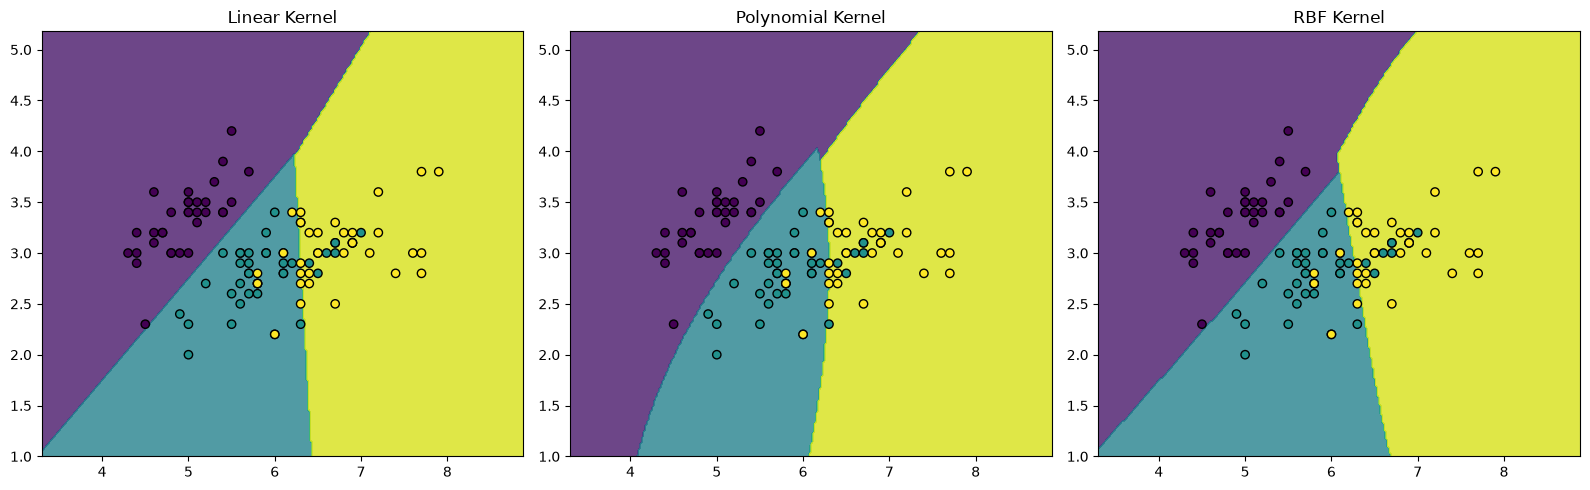

In [5]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
X_train_2d = X_train[:, :2]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, kernel_args) in zip(axes, [
    ('Linear', dict(kernel='linear')),
    ('Polynomial', dict(kernel='poly')),
    ('RBF', dict(kernel='rbf')),
]):
    model_2d = SVC(**kernel_args).fit(X_train_2d, y_train)
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8)
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolors='k')
    ax.set_title(f'{name} Kernel')
plt.tight_layout()
plt.show()


Although the three boundaries look broadly similar at first glance, each kernel produces a visibly different decision surface. In real business settings, even small differences like these can translate into meaningfully different classification outcomes.

Beyond linear, polynomial, and RBF, the sigmoid kernel and custom kernel functions are also available for domain-specific problems.

## Tuning SVM Parameters

As with most models, SVM performance can be improved through hyperparameter tuning — particularly `C` (regularization strength) and kernel-specific parameters like `degree` (polynomial) or `gamma` (RBF). We use `GridSearchCV` to search for the best combination.

In [6]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3, 4]
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.3f}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(f"Test set accuracy: {accuracy_score(y_test, y_pred):.3f}")


Best parameters: {'C': 0.1, 'degree': 4, 'kernel': 'poly'}
Best cross-validation score: 0.990
Test set accuracy: 0.933


Interestingly, tuned accuracy ($93.3\%$) landed right back at the default-parameter result on the test set — the cross-validation score ($99\%$) was noticeably higher, which is a reminder that CV scores and held-out test accuracy can diverge, especially on small, relatively easy datasets like Iris where many configurations converge to similar performance.

`C` controls the trade-off between margin width and misclassification tolerance — a larger `C` makes the model less tolerant of mistakes. Let's see how `C` affects cross-validation score directly.

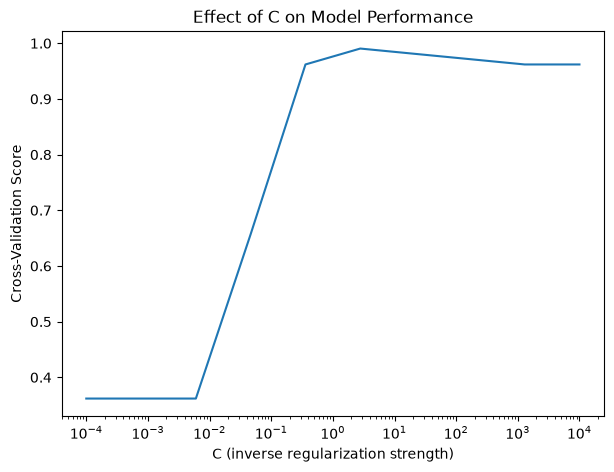

In [7]:
param_grid_c = {'C': np.logspace(-4, 4, 10), 'kernel': ['rbf']}
grid_search_c = GridSearchCV(SVC(), param_grid_c, cv=5)
grid_search_c.fit(X_train, y_train)

plt.figure(figsize=(7, 5))
plt.plot(grid_search_c.param_grid['C'], grid_search_c.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('C (inverse regularization strength)')
plt.ylabel('Cross-Validation Score')
plt.title('Effect of C on Model Performance')
plt.show()


The curve flattens out after a certain point — there are **diminishing returns** to increasing `C` further, and pushing it too high can even hurt performance by encouraging overfitting.

Beyond grid search, `RandomizedSearchCV` can sample hyperparameter combinations randomly — sometimes just as effective and considerably cheaper for large search spaces.

## SVMs in High-Dimensional Spaces

SVM is known to perform well on high-dimensional (*wide*) data — situations where the number of features far exceeds the number of samples, such as genomic data or dense sensor readings. We simulate this condition with a synthetic dataset.

In [8]:
X_hd, y_hd = make_classification(
    n_samples=1000, n_features=1000, n_informative=50, n_redundant=0, random_state=2024
)
X_train_hd, X_test_hd, y_train_hd, y_test_hd = train_test_split(
    X_hd, y_hd, test_size=0.3, random_state=2024
)

svm_hd = SVC(kernel='linear')
svm_hd.fit(X_train_hd, y_train_hd)
y_pred_hd = svm_hd.predict(X_test_hd)

print(f"Accuracy on 1000-feature data: {accuracy_score(y_test_hd, y_pred_hd):.3f}")


Accuracy on 1000-feature data: 0.747


With default parameters alone, accuracy sits around **$74.7\%$** — noticeably weaker than on the lower-dimensional Iris data, which illustrates why hyperparameter tuning matters even more in high-dimensional settings. To get a sense of the data's structure visually, we can project it down to 2D using PCA (keeping in mind this is still just a "flattened" view of the real, much higher-dimensional data).

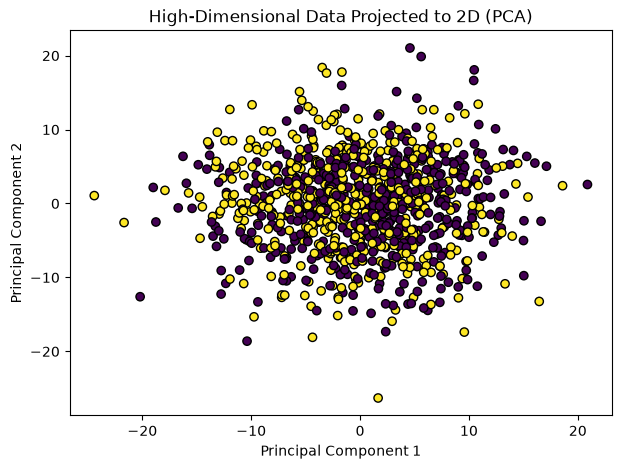

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_hd)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_hd, edgecolors='k')
plt.title('High-Dimensional Data Projected to 2D (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In the 2D projection, both classes overlap heavily — a sign that a simple linear classifier struggles to find clean separation at this low dimensionality, even though the data may be far more separable in its original, much higher-dimensional space.

**Another important consideration**: in high-dimensional settings, $\ell_1$/$\ell_2$ regularization becomes especially important to prevent overfitting by dampening the influence of irrelevant features.

## Evaluating SVM Models

SVM performance is evaluated with the same metrics used for other classifiers: accuracy, precision, recall, $F_1$-score, as well as the ROC curve and AUC. This time we switch to the *Breast Cancer* dataset.

In [10]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose().round(3)


,precision,recall,f1-score,support
0,0.926,0.940,0.933,67.000
1,0.961,0.952,0.957,104.000
accuracy,0.947,0.947,0.947,0.947
macro avg,0.944,0.946,0.945,171.000
weighted avg,0.948,0.947,0.947,171.000


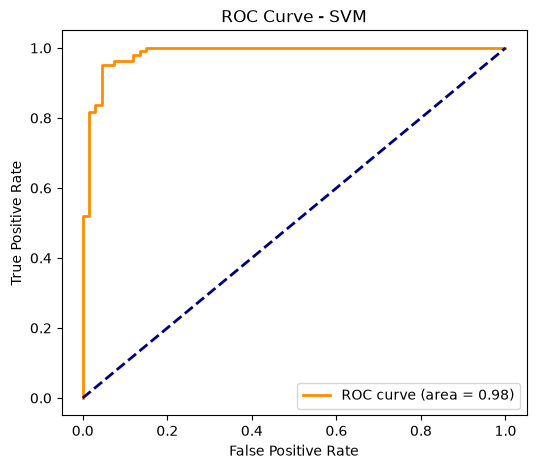

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.show()


The ROC AUC comes out near $0.98$, confirming the model is nearly perfect at ranking malignant cases above benign ones across thresholds. Note that `probability=True` is required on `SVC` to obtain probability estimates (needed for the ROC curve) — fitting is a little slower as a result, since scikit-learn performs an internal cross-validation pass to calibrate the probabilities.

As always, the "best" metric depends on context: if false positives are expensive, precision matters more; if catching every positive case is the priority, recall takes precedence.

---
## Chapter Summary

- SVM finds the hyperplane that **maximizes the margin** between classes, with the closest points (support vectors) determining that boundary. A linear-kernel SVM reached **$93.3\%$** accuracy on Iris with default parameters alone.
- **Kernels** (linear, polynomial, RBF) let SVM handle non-linearly separable data by implicitly mapping it into a higher-dimensional space (the *kernel trick*) — on Iris, the polynomial kernel had a slight edge over linear and RBF.
- Hyperparameter tuning (`C`, `degree`, `gamma`) via grid/random search is important, though on well-behaved datasets, the gains over default settings can be modest.
- SVM is well suited to **high-dimensional data** (many more features than samples) but needs more careful tuning there — accuracy dropped to **$74.7\%$** on a 1000-feature synthetic dataset using default parameters.
- SVM evaluation follows standard classification metrics; on Breast Cancer, the model reached an AUC near **$0.98$**, showing near-perfect discrimination ability between malignant and benign cases.